## 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from warnings import filterwarnings
filterwarnings('ignore')

## 2. Load Dataset

In [2]:
df = pd.read_csv('dataset/diabetic_data.csv')
y_target = 'readmitted'
df.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
df.describe(include='object')

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


## 4. Missing & Duplicate Values Analysis

In [7]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage
A1Cresult,84748,83.28
max_glu_serum,96420,94.75


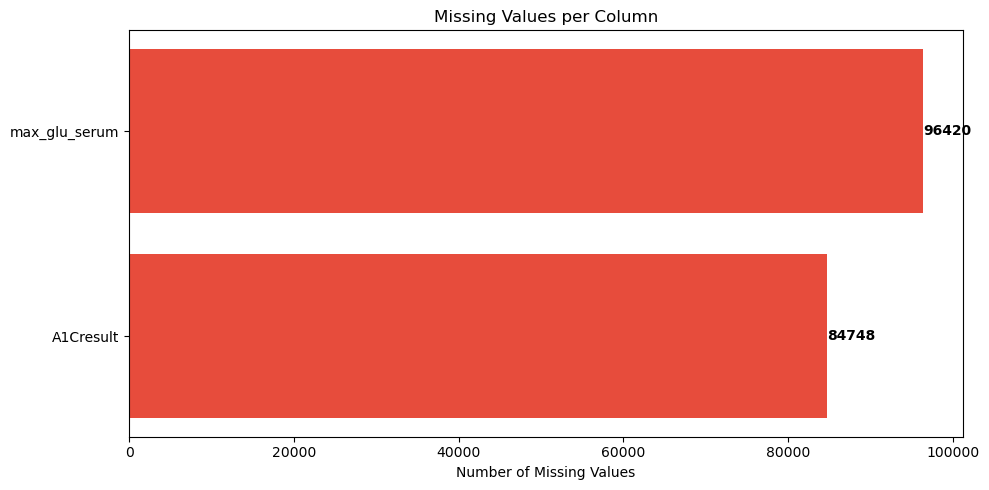

In [8]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage


## 5. Target Variabel Distribution

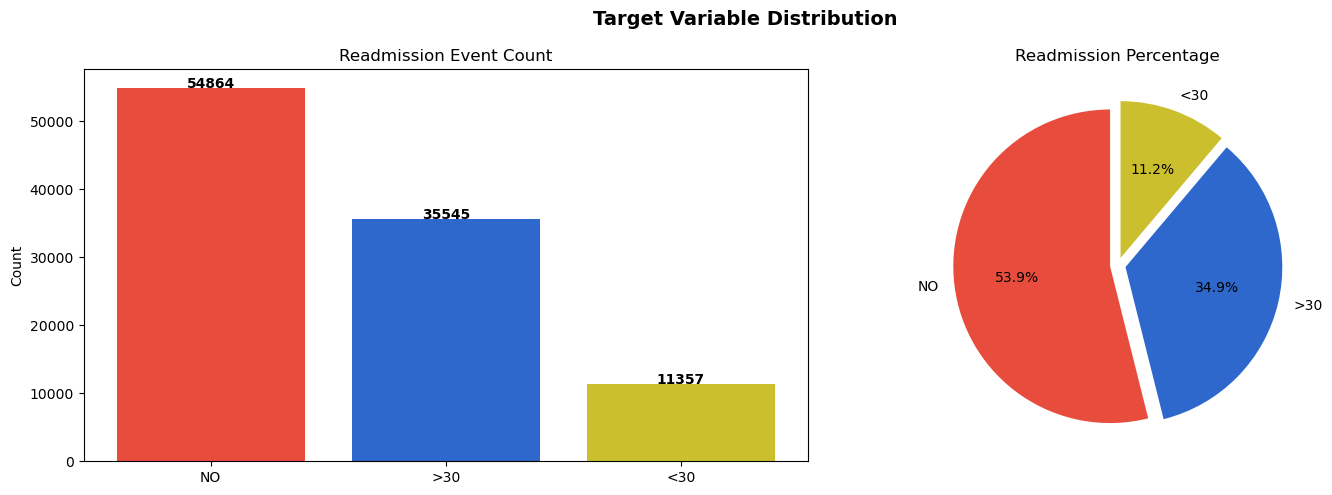

noRedmission rate: 53.91%
under30 rate: 11.16%
upper30 rate: 34.93%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
readmission_patient = df[y_target].value_counts()
labels_x = readmission_patient.index

# Count plot
axes[0].bar(labels_x, readmission_patient.values,
            color=["#e74c3c", "#2e68cc", "#ccbf2e"])
axes[0].set_title("Readmission Event Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(readmission_patient.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(readmission_patient.values, labels=labels_x,
            autopct="%1.1f%%", colors=["#e74c3c", "#2e68cc", "#ccbf2e"],
            startangle=90, explode=(0.05, 0.05,0.05))
axes[1].set_title("Readmission Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
noRedmission_rate = (len(df[df[y_target] == labels_x[0]] )/ len(df))
upper30_rate = (len(df[df[y_target] == labels_x[1]]) / len(df))
under30_rate = (len(df[df[y_target] == labels_x[2]]) / len(df))

print(f'noRedmission rate: {noRedmission_rate:.2%}')
print(f'under30 rate: {under30_rate:.2%}')
print(f'upper30 rate: {upper30_rate:.2%}')

In [25]:
df[y_target].describe(include='object')

count     101766
unique         3
top           NO
freq       54864
Name: readmitted, dtype: object

## 6. Univariate Analysis — Numerical Features

In [28]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (13):
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


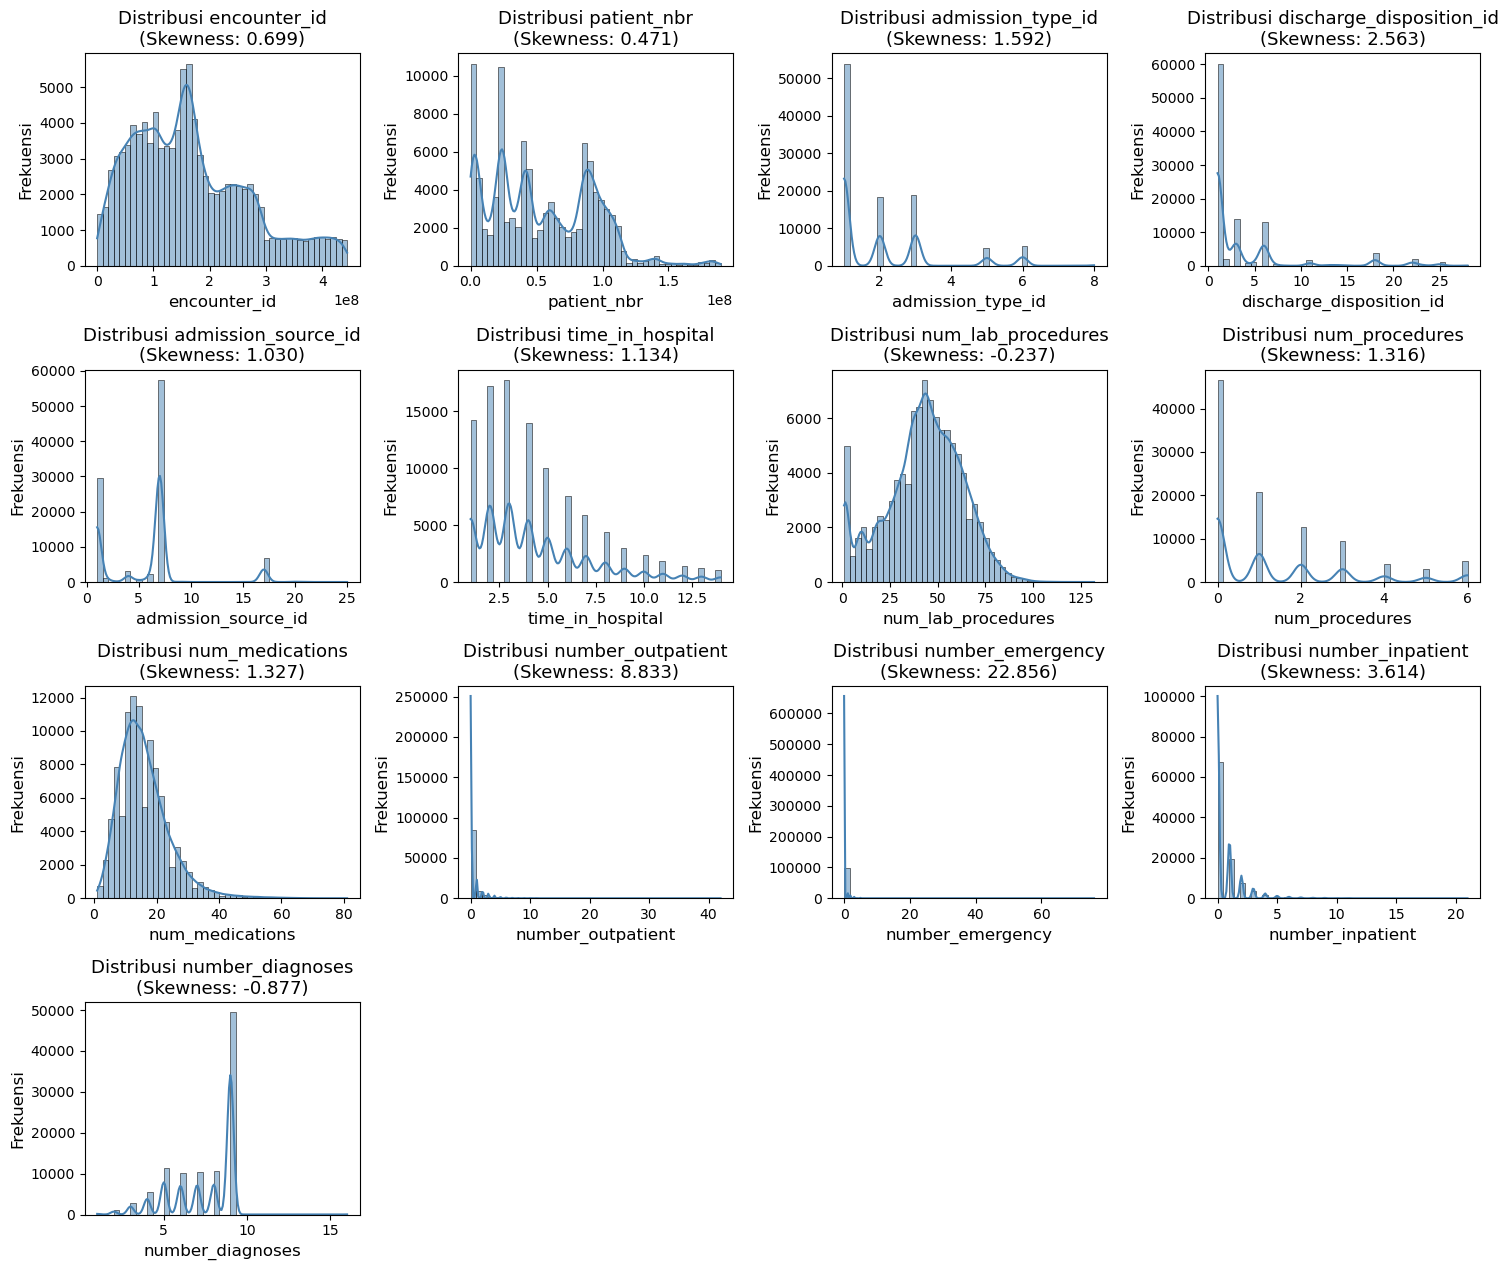

In [30]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

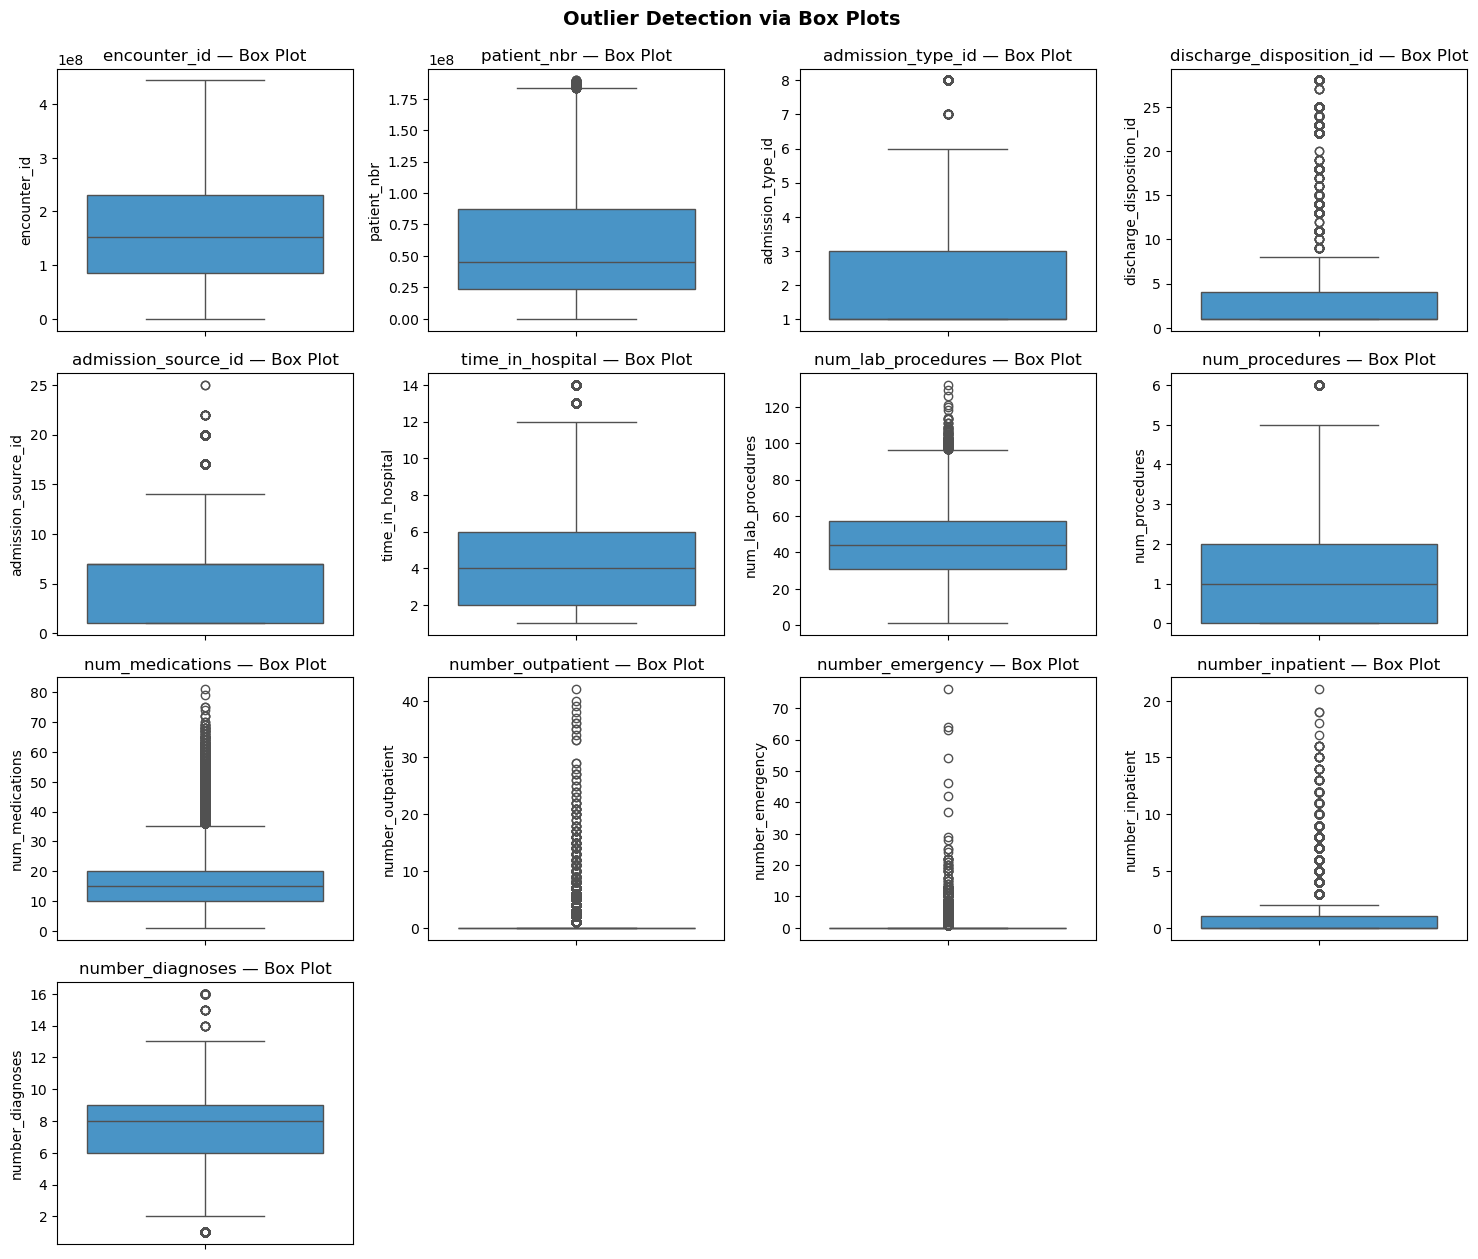

In [32]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features Numerik VS Target

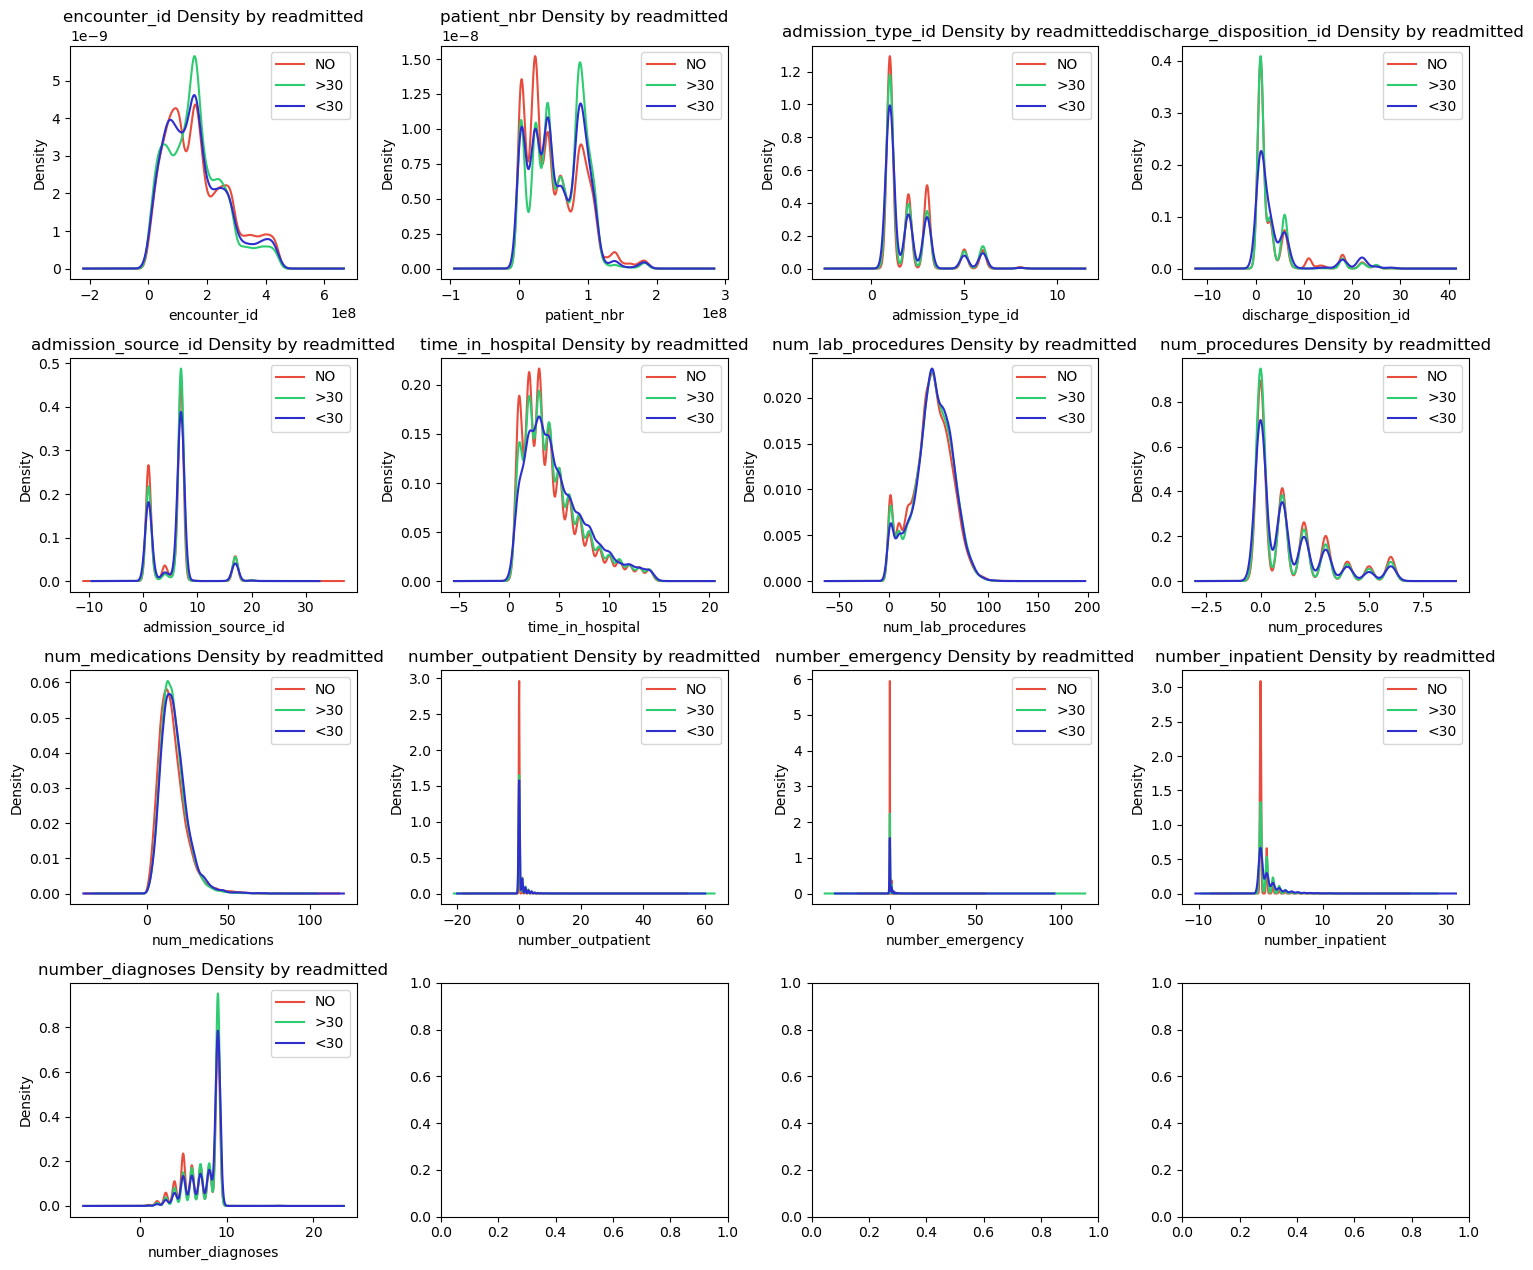

In [34]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,col in enumerate(feature_numerik):
    df[df[y_target] == labels_x[0]][col].dropna().plot.kde(ax=axes[i],color="#e74c3c",label=labels_x[0])
    df[df[y_target] == labels_x[1]][col].dropna().plot.kde(ax=axes[i],color="#2ecc71",label=labels_x[1])
    df[df[y_target] == labels_x[2]][col].dropna().plot.kde(ax=axes[i],color="#2e2ecc",label=labels_x[2])
    axes[i].set_title(f'{col} Density by {y_target}')
    axes[i].set_xlabel(f'{col}')
    axes[i].legend()
plt.tight_layout()
plt.show()

## 8. Multivariat Analysis

In [37]:
df_target = df.copy()

mapping_status = {labels_x[0]:0,labels_x[0]:1,labels_x[2]:2}
df_target[y_target] = df_target[y_target].map(mapping_status)

feature_numerik = df_target.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df_target[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:25]

print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
number_inpatient            0.271
number_emergency            0.125
number_diagnoses            0.090
time_in_hospital            0.065
number_outpatient           0.057
num_medications             0.055
discharge_disposition_id    0.047
num_lab_procedures          0.035
patient_nbr                 0.033
num_procedures              0.028
encounter_id                0.022
admission_source_id         0.020
admission_type_id           0.014
Name: readmitted, dtype: float64


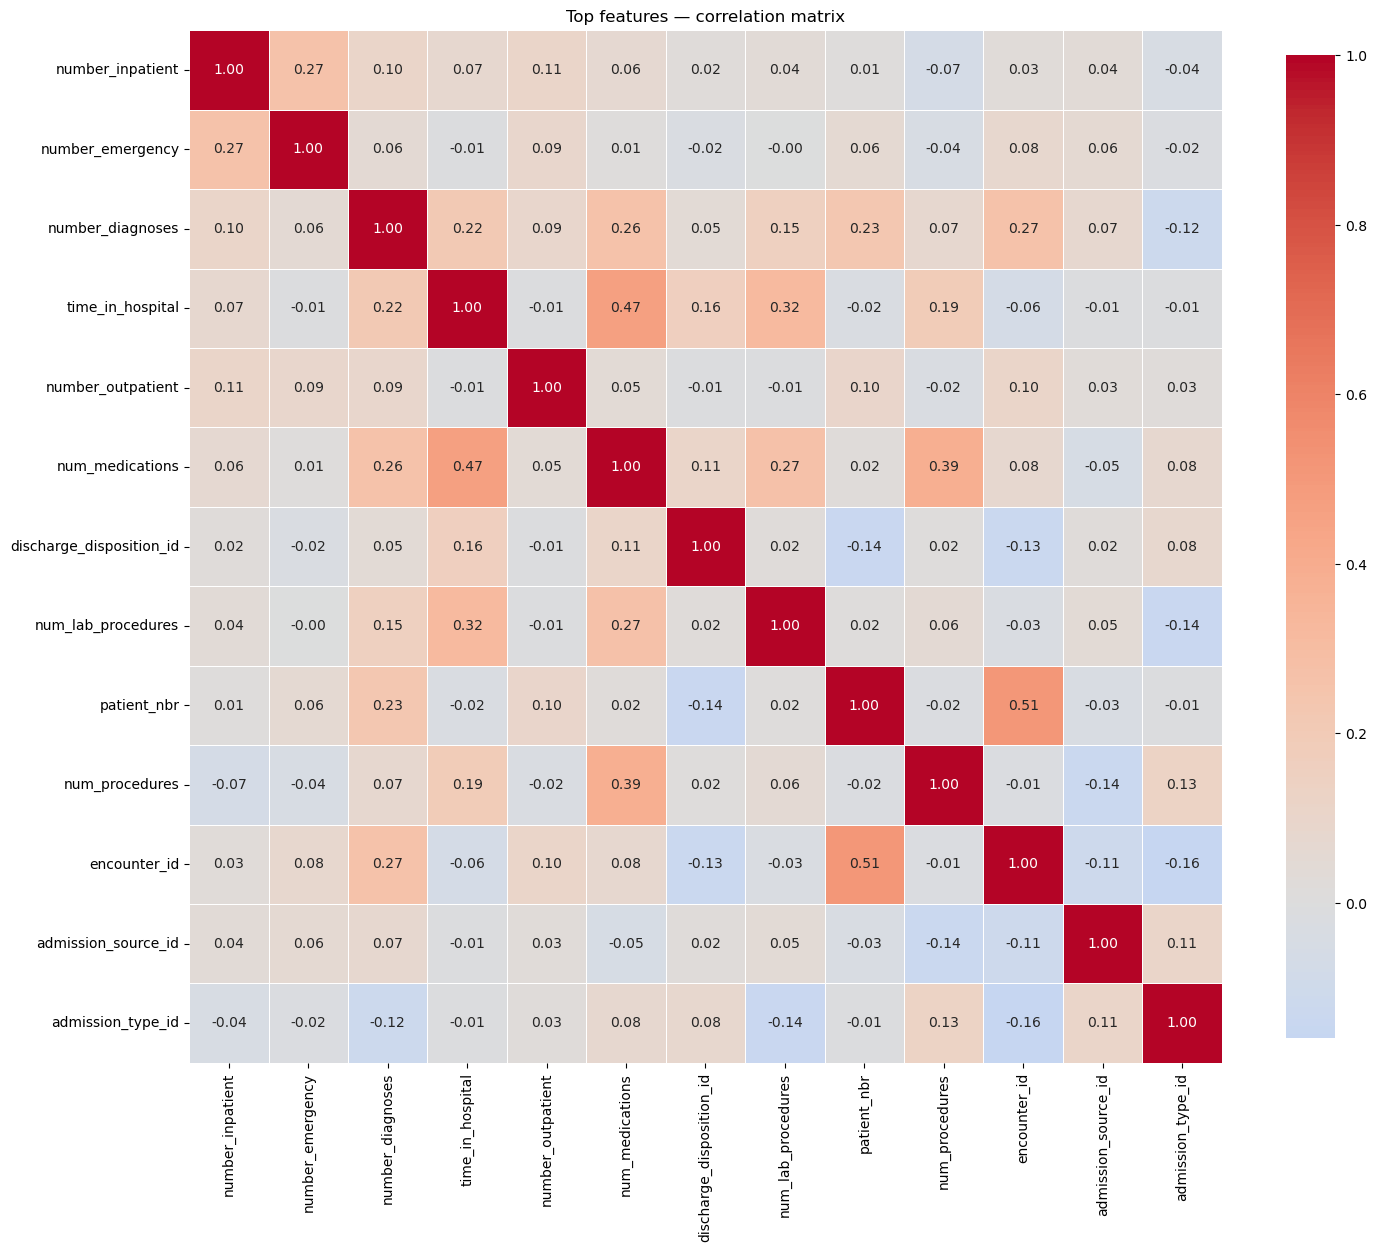

In [38]:
corr_matrix = df_target[top_features].corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

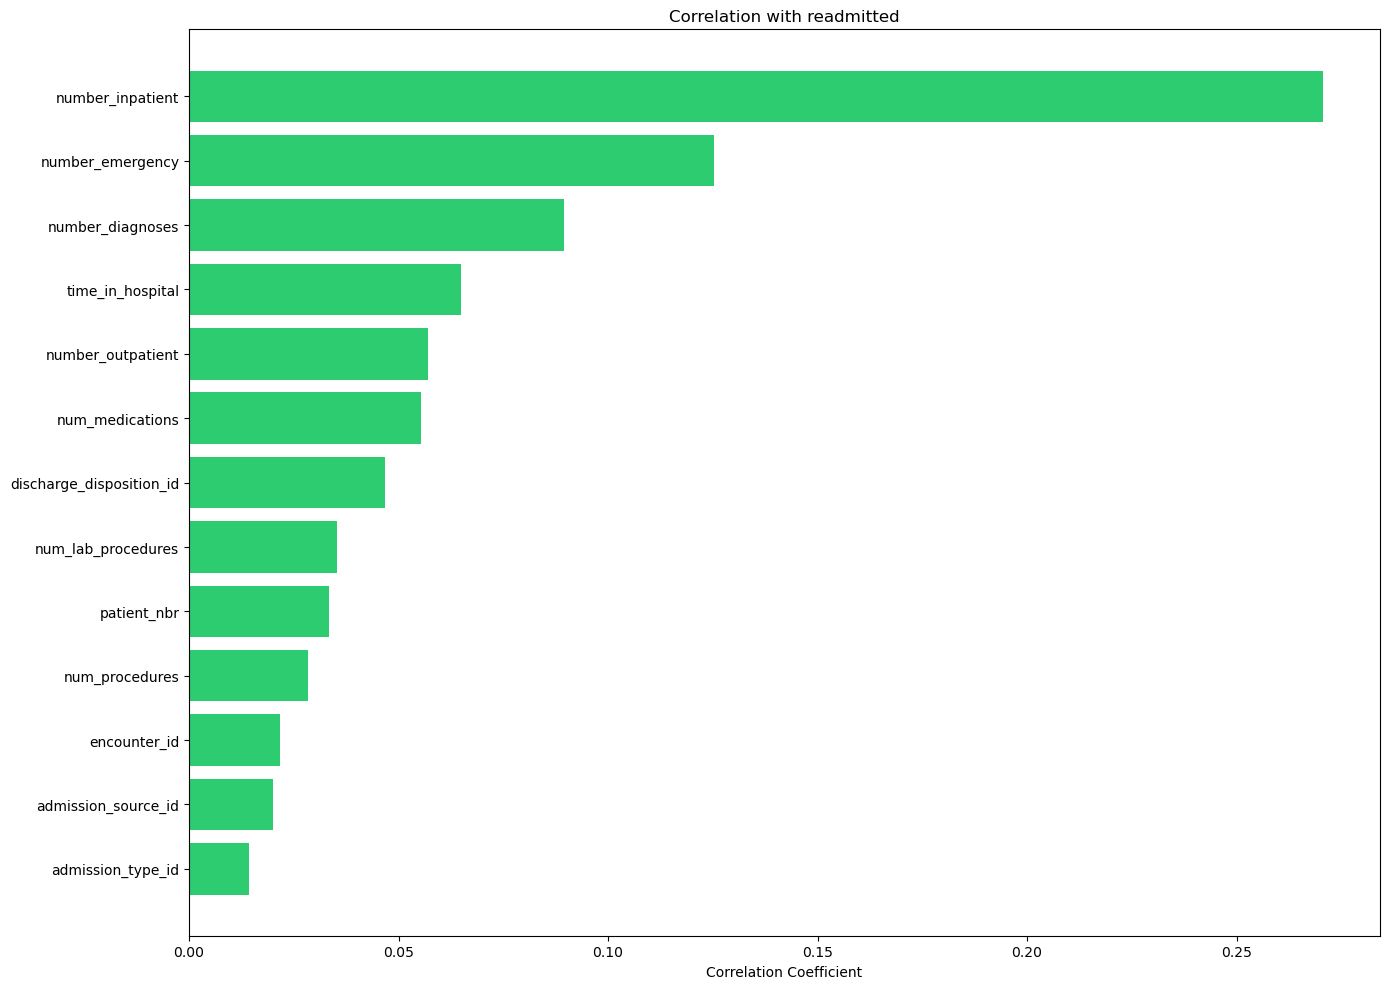

In [40]:
# Correlation with target
target_corr = df_target[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 9.Summary of EDA Findings

In [42]:
mapping_status = {'Graduate':0,'Dropout':1,'Enrolled':2}
df[y_target] = df[y_target].map(mapping_status)
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,101766
1,Total features,49
2,Target mean,NaN
3,Target median,NaN
4,Target stddev,NaN
5,Target min,NaN
6,Target max,NaN
7,Target skewness,NaN
8,Top correlated feature,number_inpatient
9,Top correlation value,0.271
